In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph
from tqec.computation.correlation import find_correlation_surfaces

import mqt.qecc

import temp_utils

import numpy as np

In [2]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(0,0,2), "Port", "top"),
    (Position3DHex(0,0,0), "Port", "bottom"),
    (Position3DHex(1,1,1), "Port", "left"),
    (Position3DHex(-1,1,1), "Port", "right"),
    (Position3DHex(1,-1,1), "Port", "down"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [3]:
#middle bottom
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#middle top
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#middle left
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

#middle right
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[4][0], pipe_kind)

#middle down
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[5][0], pipe_kind)

In [22]:
g = PrismGraph("Id-rank3s")

prisms = [
    (Position3DHex(-1, 5, 0), "PORT", "in-5"),
    (Position3DHex(-3, 5, 0), "PORT", "in-4"),
    (Position3DHex(-2, 4, 0), "NN", ""),
    (Position3DHex(-1, 3, 0), "ZZ", ""),
    (Position3DHex(0, 0, 0), "PORT", "in-1"),
    (Position3DHex(1, 1, 0), "ZZ", ""),
    (Position3DHex(0, 2, 0), "ZZ", ""),
    (Position3DHex(2, 0, 0), "ZZ", ""),
    (Position3DHex(3, 1, 0), "ZZ", ""),
    (Position3DHex(4, 0, 0), "NN", ""),
    (Position3DHex(5, 1, 0), "PORT", "in-2"),
    (Position3DHex(5, -1, 0), "PORT", "in-3"),

    #vertical ports
    (Position3DHex(-2, 4, 1), "PORT", "in-6"),
    (Position3DHex(-2, 4, -1), "PORT", "in-7"),

    (Position3DHex(4, 0, 1), "PORT", "in-8"),
    (Position3DHex(4, 0, -1), "PORT", "in-9"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [23]:
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[3][0], prisms[2][0], pipe_kind)

g.add_pipe(prisms[3][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[4][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[7][0], pipe_kind)

g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

g.add_pipe(prisms[5][0], prisms[6][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[8][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[10][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[11][0], pipe_kind)

#vertical pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[12][0], pipe_kind)
g.add_pipe(prisms[2][0], prisms[13][0], pipe_kind)

g.add_pipe(prisms[9][0], prisms[14][0], pipe_kind)
g.add_pipe(prisms[9][0], prisms[15][0], pipe_kind)

In [32]:
z=0
d=5
stabs_x, stabs_z, _, dct_single_type_stabs, dct_patch_stabilizers = g.stabilizers_timeslice(z,d)

In [33]:
star_ops_x, star_ops_z = g.star_operator_timeslice(z, d)
print(len(star_ops_x), len(star_ops_z))

0 1


X stabilizers + X logical


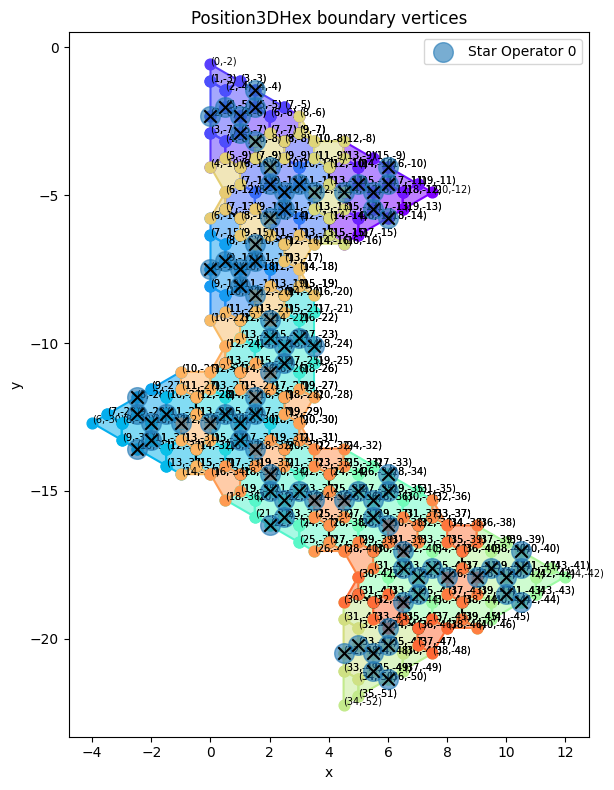

In [34]:
print("X stabilizers + X logical")
temp_utils.plot_position_dict(size = (8,8),stabilizers=stabs_x, star_op=star_ops_z)

In [35]:
pos_to_int = temp_utils.build_position_encoding(stabs_x)

trans_z = temp_utils.translate_stabilizers(stabs_z, pos_to_int)
trans_x = temp_utils.translate_stabilizers(stabs_x, pos_to_int)

num_qubits = len(pos_to_int.values())

hz = temp_utils.build_check_matrix(trans_z, num_qubits)
hx = temp_utils.build_check_matrix(trans_x, num_qubits)

#if csscode runs, we actually have a valid code in which all stabilizers commute
csscode = mqt.qecc.codes.css_code.CSSCode(d, hx, hz)
print("CSSCode successfully constructed...")

star_op = [star_ops_z[0]] #change shape to make next function work
star_op = temp_utils.translate_stabilizers(star_op, pos_to_int) #use the stabilizer translation function also for logical ops
star_op = temp_utils.build_check_matrix(star_op, num_qubits)
check = temp_utils.check_logical_operator(star_op, hz)
print("The X logical commutes with all Z stabilizers:", check)

star_op = [star_ops_z[0]] #change shape to make next function work
star_op = temp_utils.translate_stabilizers(star_op, pos_to_int) #use the stabilizer translation function also for logical ops
star_op = temp_utils.build_check_matrix(star_op, num_qubits)
check = temp_utils.check_logical_operator(star_op, hx)
print("The Z logical commutes with all X stabilizers:", check)


CSSCode successfully constructed...
The X logical commutes with all Z stabilizers: True
The Z logical commutes with all X stabilizers: True


In [36]:
result = g.stabilizer_product_timeslice(z, d, dct_single_type_stabs, dct_patch_stabilizers, testing = True)
print(len(result.stabilizer_products_x), len(result.stabilizer_products_z))

stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
stabilizer tests passed
10 0


Position3DHex(x=-1, y=5, z=0)
Position3DHex(x=-2, y=4, z=0)
Position3DHex(x=-1, y=3, z=0)
Position3DHex(x=0, y=2, z=0)
Position3DHex(x=1, y=1, z=0)
Position3DHex(x=0, y=0, z=0)


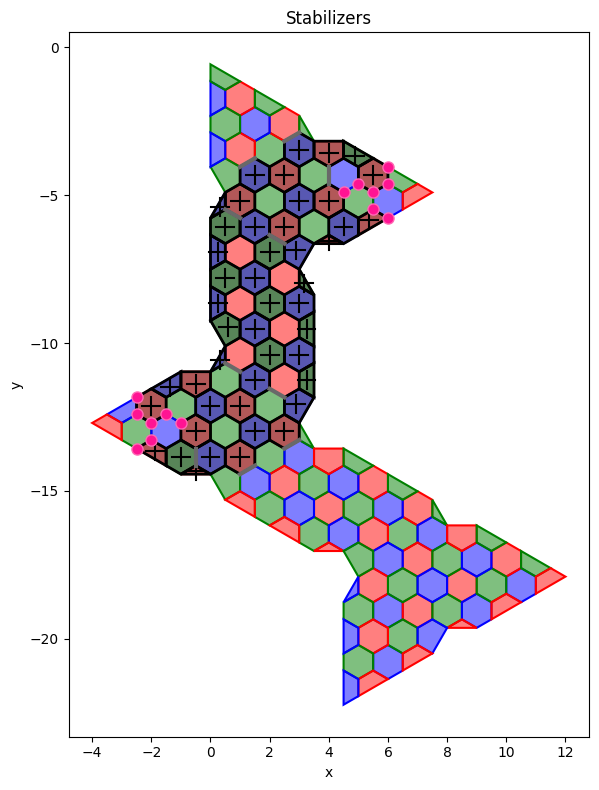

In [37]:
all_paths_stabilizer_product = result.stabilizer_products_x
assignment = result.assignment#
all_paths_stars = result.stars_x
all_paths = result.paths_x
idx = 0
for el in all_paths[idx]:
    print(el)
temp_utils.plot_position_dict_3color(size = (8,8), color_assignment=assignment, stabilizer_product = all_paths_stabilizer_product[idx], star_operators = all_paths_stars[idx], show_positions = False)